In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import os

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohitudageri/credit-card-details")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\rohitudageri\credit-card-details\versions\1


In [19]:
df_path = os.path.join(path, 'Credit_card.csv')
df2_path = os.path.join(path, 'Credit_card_label.csv')

df = pd.read_csv(df_path)
df2 = pd.read_csv(df2_path)

In [20]:
df

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,5028645,F,N,Y,0,NaN,Commercial associate,Higher education,Married,House / apartment,-11957.0,-2182,1,0,0,0,Managers,2
1544,5023655,F,N,N,0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229.0,-1209,1,0,0,0,Accountants,1
1545,5115992,M,Y,Y,2,180000.0,Working,Higher education,Married,House / apartment,-13174.0,-2477,1,0,0,0,Managers,4
1546,5118219,M,Y,N,0,270000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-15292.0,-645,1,1,1,0,Drivers,2


In [21]:
df2

,Ind_ID,label
0,5008827,1
1,5009744,1
2,5009746,1
3,5009749,1
4,5009752,1
...,...,...
1543,5028645,0
1544,5023655,0
1545,5115992,0
1546,5118219,0


In [22]:
df = df.merge(df2[['Ind_ID', 'label']], on='Ind_ID', how='left')
df = df.drop(['Ind_ID', 'Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID'], axis=1)

In [23]:
df

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Type_Occupation,Family_Members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,NaN,2,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,NaN,2,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,NaN,2,1
3,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,NaN,2,1
4,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,NaN,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,F,N,Y,0,NaN,Commercial associate,Higher education,Married,House / apartment,-11957.0,-2182,Managers,2,0
1544,F,N,N,0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229.0,-1209,Accountants,1,0
1545,M,Y,Y,2,180000.0,Working,Higher education,Married,House / apartment,-13174.0,-2477,Managers,4,0
1546,M,Y,N,0,270000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-15292.0,-645,Drivers,2,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   GENDER           1541 non-null   object 
 1   Car_Owner        1548 non-null   object 
 2   Propert_Owner    1548 non-null   object 
 3   CHILDREN         1548 non-null   int64  
 4   Annual_income    1525 non-null   float64
 5   Type_Income      1548 non-null   object 
 6   EDUCATION        1548 non-null   object 
 7   Marital_status   1548 non-null   object 
 8   Housing_type     1548 non-null   object 
 9   Birthday_count   1526 non-null   float64
 10  Employed_days    1548 non-null   int64  
 11  Type_Occupation  1060 non-null   object 
 12  Family_Members   1548 non-null   int64  
 13  label            1548 non-null   int64  
dtypes: float64(2), int64(4), object(8)
memory usage: 169.4+ KB


In [25]:
df.describe()

,CHILDREN,Annual_income,Birthday_count,Employed_days,Family_Members,label
count,1548.000000,1.525000e+03,1526.000000,1548.000000,1548.000000,1548.000000
mean,0.412791,1.913993e+05,-16040.342071,59364.689922,2.161499,0.113049
std,0.776691,1.132530e+05,4229.503202,137808.062701,0.947772,0.316755
min,0.000000,3.375000e+04,-24946.000000,-14887.000000,1.000000,0.000000
25%,0.000000,1.215000e+05,-19553.000000,-3174.500000,2.000000,0.000000
50%,0.000000,1.665000e+05,-15661.500000,-1565.000000,2.000000,0.000000
75%,1.000000,2.250000e+05,-12417.000000,-431.750000,3.000000,0.000000
max,14.000000,1.575000e+06,-7705.000000,365243.000000,15.000000,1.000000


In [26]:
print(f"Баланс классов:\n{df['label'].value_counts()}")

Баланс классов:
label
0    1373
1     175
Name: count, dtype: int64


In [27]:
#X = df.drop('label', axis=1)
#y = df['label']

In [28]:
numeric_cols = ['CHILDREN', 'Annual_income', 'Birthday_count', 'Employed_days', 'Family_Members']
categorical_cols = ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Type_Occupation']

In [29]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


GENDER:
GENDER
F    973
M    568
Name: count, dtype: int64

Car_Owner:
Car_Owner
N    924
Y    624
Name: count, dtype: int64

Propert_Owner:
Propert_Owner
Y    1010
N     538
Name: count, dtype: int64

Type_Income:
Type_Income
Working                 798
Commercial associate    365
Pensioner               269
State servant           116
Name: count, dtype: int64

EDUCATION:
EDUCATION
Secondary / secondary special    1031
Higher education                  426
Incomplete higher                  68
Lower secondary                    21
Academic degree                     2
Name: count, dtype: int64

Marital_status:
Marital_status
Married                 1049
Single / not married     227
Civil marriage           101
Separated                 96
Widow                     75
Name: count, dtype: int64

Housing_type:
Housing_type
House / apartment      1380
With parents             80
Municipal apartment      53
Rented apartment         21
Office apartment          9
Co-op apartment          

In [30]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,   # use sparse=False if sklearn < 1.2
    handle_unknown='ignore'
)

encoded = encoder.fit_transform(df[categorical_cols]) 

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df.index
)

# Combine back with numerical columns
df_final = pd.concat(
    [df.drop(columns=categorical_cols), encoded_df],
    axis=1
)

print(df_final)

      CHILDREN  Annual_income  Birthday_count  Employed_days  Family_Members  \
0            0       180000.0        -18772.0         365243               2   
1            0       315000.0        -13557.0           -586               2   
2            0       315000.0             NaN           -586               2   
3            0            NaN        -13557.0           -586               2   
4            0       315000.0        -13557.0           -586               2   
...        ...            ...             ...            ...             ...   
1543         0            NaN        -11957.0          -2182               2   
1544         0       225000.0        -10229.0          -1209               1   
1545         2       180000.0        -13174.0          -2477               4   
1546         0       270000.0        -15292.0           -645               2   
1547         0       225000.0        -16601.0          -2859               2   

      label  GENDER_F  GENDER_M  GENDER

In [31]:
df_final

,CHILDREN,Annual_income,Birthday_count,Employed_days,Family_Members,label,GENDER_F,GENDER_M,GENDER_nan,Car_Owner_N,...,Type_Occupation_Low-skill Laborers,Type_Occupation_Managers,Type_Occupation_Medicine staff,Type_Occupation_Private service staff,Type_Occupation_Realty agents,Type_Occupation_Sales staff,Type_Occupation_Secretaries,Type_Occupation_Security staff,Type_Occupation_Waiters/barmen staff,Type_Occupation_nan
0,0,180000.0,-18772.0,365243,2,1,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,315000.0,-13557.0,-586,2,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,315000.0,NaN,-586,2,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,NaN,-13557.0,-586,2,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,315000.0,-13557.0,-586,2,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,0,NaN,-11957.0,-2182,2,0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1544,0,225000.0,-10229.0,-1209,1,0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1545,2,180000.0,-13174.0,-2477,4,0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1546,0,270000.0,-15292.0,-645,2,0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
y = df_final['label']
x = df_final.drop(columns = ['label'])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [37]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
cross_val_score(clf, x_train, y_train, cv=10)

array([0.88709677, 0.89516129, 0.87096774, 0.87903226, 0.88709677,
       0.87903226, 0.88709677, 0.88709677, 0.89430894, 0.86178862])

In [38]:
clf.fit(x_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [39]:
print(clf.score(x_train, y_train))
print(clf.score(x_test, y_test))

0.8974151857835219
0.8903225806451613


[Text(0.71875, 0.9166666666666666, 'x[7] <= 0.5\ngini = 0.207\nsamples = 1238\nvalue = [1093, 145]'),
 Text(0.5375, 0.75, 'x[3] <= -1460.0\ngini = 0.201\nsamples = 1232\nvalue = [1092, 140]'),
 Text(0.628125, 0.8333333333333333, 'True  '),
 Text(0.325, 0.5833333333333334, 'x[13] <= 0.5\ngini = 0.135\nsamples = 647\nvalue = [600, 47]'),
 Text(0.2, 0.4166666666666667, 'x[28] <= 0.5\ngini = 0.127\nsamples = 643\nvalue = [599, 44]'),
 Text(0.1, 0.25, 'x[19] <= 0.5\ngini = 0.117\nsamples = 625\nvalue = [586, 39]'),
 Text(0.05, 0.08333333333333333, 'gini = 0.112\nsamples = 620\nvalue = [583, 37]'),
 Text(0.15, 0.08333333333333333, 'gini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.3, 0.25, 'x[1] <= 204750.0\ngini = 0.401\nsamples = 18\nvalue = [13, 5]'),
 Text(0.25, 0.08333333333333333, 'gini = 0.305\nsamples = 16\nvalue = [13, 3]'),
 Text(0.35, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.45, 0.4166666666666667, 'x[2] <= -19323.0\ngini = 0.375\nsamples = 4\nval

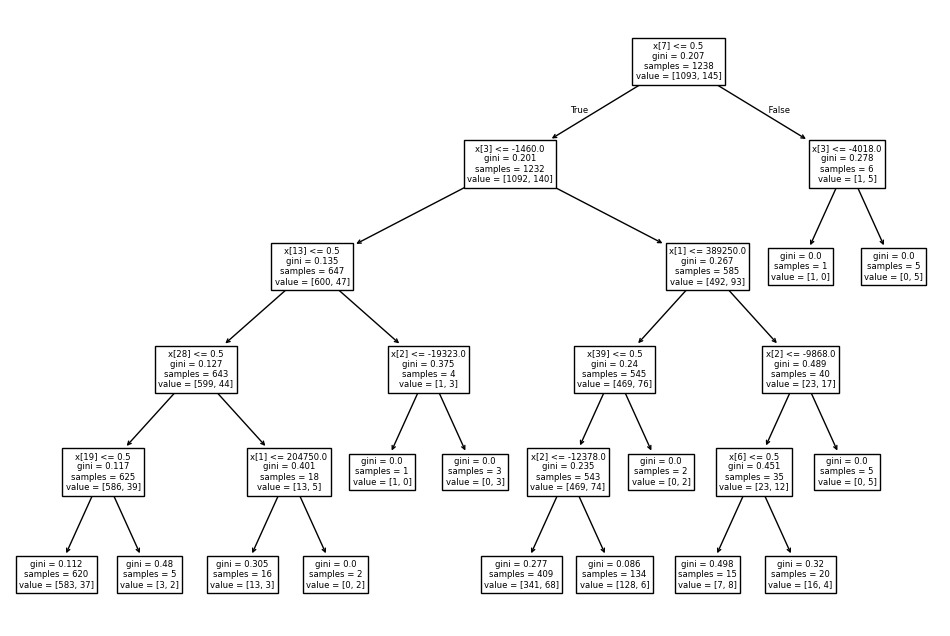

In [40]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(clf) 

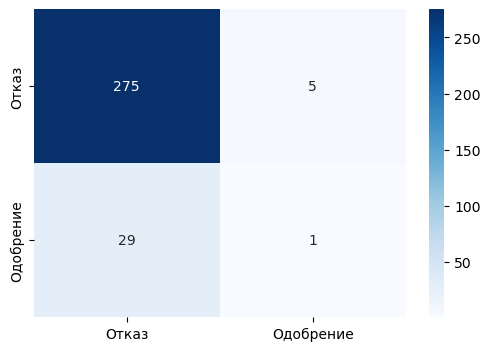

In [44]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, clf.predict(x_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Отказ', 'Одобрение'],
            yticklabels=['Отказ', 'Одобрение'])
plt.show()